In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
# standard data access code
import os
import sys
import platform
from allensdk.core.brain_observatory_cache import BrainObservatoryCache

# Set file location based on platform.
platstring = platform.platform()
if ('Darwin' in platstring) or ('macOS' in platstring):
    # macOS
    data_root = "/Volumes/TReND2025/"
elif 'Windows'  in platstring:
    # Windows (replace with the drive letter of USB drive)
    data_root = "E:/"
elif ('amzn' in platstring) or ('google.colab' in sys.modules):
    # then on Code Ocean or Colab
    data_root = "/data/"
elif 'Linux' in platstring:
    # then your own linux platform
    # EDIT location where you mounted hard drive
    data_root = "/media/$USERNAME/TReND2025/"

# if running locally without external drive, set a local path to download data
# data_root = '/path/to/data'

manifest_file = os.path.join(data_root,'allen-brain-observatory/visual-coding-2p/manifest.json')
boc = BrainObservatoryCache(manifest_file=manifest_file)

In [3]:
# check that the manifest loaded successfully
print("Manifest file loaded from:", manifest_file)

# list available experiment containers (each is a unique imaging site across 3 sessions)
containers = boc.get_experiment_containers()
print(f"Total experiment containers available: {len(containers)}")

# show first few entries to inspect what data look like
pd.DataFrame(containers[:5])

Manifest file loaded from: E:/allen-brain-observatory/visual-coding-2p/manifest.json
Total experiment containers available: 456


,id,imaging_depth,targeted_structure,cre_line,reporter_line,donor_name,specimen_name,tags,failed
0,660492886,275,VISal,Sst-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),306500,Sst-IRES-Cre;Ai148(CAM)-306500,[],False
1,651773425,375,VISl,Fezf2-CreER,Ai148(TIT2L-GC6f-ICL-tTA2),351315,Fezf2-CreER;Ai148-351315,[],False
2,546328009,350,VISal,Nr5a1-Cre,Ai93(TITL-GCaMP6f),261969,Nr5a1-Cre;Camk2a-tTA;Ai93-261969,[],False
3,661437138,175,VISp,Slc17a7-IRES2-Cre,Ai93(TITL-GCaMP6f),365251,Slc17a7-IRES2-Cre;Camk2a-tTA;Ai93-365251,[],False
4,511510911,350,VISp,Scnn1a-Tg3-Cre,Ai93(TITL-GCaMP6f),230570,Scnn1a-Tg3-Cre;Camk2a-tTA;Ai93-230570,[],False


In [4]:
# filter for VISp (primary visual cortex)
visp_containers = boc.get_experiment_containers(targeted_structures=['VISp'])
print(f"VISp experiment containers: {len(visp_containers)}")

# show a few example container IDs
visp_ids = [c['id'] for c in visp_containers]
print("Sample VISp container IDs:", visp_ids[:5])

VISp experiment containers: 144
Sample VISp container IDs: [661437138, 511510911, 644909309, 511510736, 528792730]


In [5]:
stimuli_of_interest = ['natural_movie_three']
exps = boc.get_ophys_experiments(experiment_container_ids=visp_ids, stimuli=stimuli_of_interest)
print(f"Found {len(exps)} experiments that include {stimuli_of_interest[0]}")
pd.DataFrame(exps[:5])

Found 144 experiments that include natural_movie_three


,id,imaging_depth,targeted_structure,cre_line,reporter_line,acquisition_age_days,experiment_container_id,session_type,donor_name,specimen_name,fail_eye_tracking
0,704298735,175,VISp,Cux2-CreERT2,Ai93(TITL-GCaMP6f),111,701412138,three_session_A,382421,Cux2-CreERT2;Camk2a-tTA;Ai93-382421,True
1,663479824,275,VISp,Vip-IRES-Cre,Ai148(TIT2L-GC6f-ICL-tTA2),126,659491615,three_session_A,360906,Vip-IRES-Cre;Ai148-360906,True
2,662033243,375,VISp,Slc17a7-IRES2-Cre,Ai93(TITL-GCaMP6f),116,661744802,three_session_A,361635,Slc17a7-IRES2-Cre;Camk2a-tTA;Ai93-361635,True
3,545446482,175,VISp,Emx1-IRES-Cre,Ai93(TITL-GCaMP6f),99,543677425,three_session_A,260936,Emx1-IRES-Cre;Camk2a-tTA;Ai93-260936,True
4,510214538,275,VISp,Rorb-IRES2-Cre,Ai93(TITL-GCaMP6f),104,511510675,three_session_A,228786,Rorb-IRES2-Cre;Camk2a-tTA;Ai93-228786,True


In [6]:
# choose the first experiment (or pick one from printed list)
exp_id = exps[0]['id']
print("Using experiment ID:", exp_id)

# load the experiment data (this reads from your local drive)
data_set = boc.get_ophys_experiment_data(exp_id)

# check available methods and metadata
print("Available methods:", dir(data_set)[:10])
print("Metadata:", data_set.get_metadata().keys())

Using experiment ID: 704298735
Available methods: ['FILE_METADATA_MAPPING', 'MOTION_CORRECTION_DATASETS', 'PIPELINE_DATASET', 'STIMULUS_TABLE_TYPES', 'SUPPORTED_PIPELINE_VERSION', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__']
Metadata: dict_keys(['sex', 'targeted_structure', 'ophys_experiment_id', 'experiment_container_id', 'excitation_lambda', 'indicator', 'fov', 'genotype', 'session_start_time', 'session_type', 'specimen_name', 'cre_line', 'imaging_depth_um', 'age_days', 'device', 'device_name', 'pipeline_version'])


In [8]:
# dF/F traces and timestamps
timestamps, dff_traces = data_set.get_dff_traces()
cell_ids = data_set.get_cell_specimen_ids()

print("n_cells:", len(cell_ids))
print("frames:", len(timestamps))

# running speed
dxcm, dxtime = data_set.get_running_speed()
aligned_dx = np.interp(timestamps, dxtime, dxcm, left=np.nan, right=np.nan)

# pupil size (some experiments may not have this)
try:
    pupil_ts, pupil_area = data_set.get_pupil_size()
    pupil_aligned = np.interp(timestamps, pupil_ts, pupil_area)
    print("Pupil data extracted successfully.")
except:
    pupil_aligned = np.full_like(timestamps, np.nan)
    print("No pupil data for this experiment.")

n_cells: 95
frames: 115498
No pupil data for this experiment.


In [9]:
# search for an experiment in VISp with both running and pupil data
exps_with_pupil = []
for exp in exps:
    exp_id = exp['id']
    ds = boc.get_ophys_experiment_data(exp_id)
    try:
        pupil_ts, pupil_area = ds.get_pupil_size()
        if len(pupil_area) > 0:
            exps_with_pupil.append(exp_id)
    except:
        continue

print("Experiments with pupil data:", exps_with_pupil)
print("Total found:", len(exps_with_pupil))

Experiments with pupil data: [528402271, 581150104, 502962794, 571137446, 577379202, 561312435, 501729039, 580163817, 570278597, 580043440, 559192380, 512270518]
Total found: 12


In [10]:
# choose one experiment with pupil data
exp_id = 528402271   # you can change this later
print("Using experiment ID:", exp_id)

# load it
data_set = boc.get_ophys_experiment_data(exp_id)

Using experiment ID: 528402271


In [11]:
# extract fluorescence traces
timestamps, dff_traces = data_set.get_dff_traces()
cell_ids = data_set.get_cell_specimen_ids()

print("n_cells:", len(cell_ids))
print("frames:", len(timestamps))

# running speed
dxcm, dxtime = data_set.get_running_speed()
aligned_dx = np.interp(timestamps, dxtime, dxcm, left=np.nan, right=np.nan)

# pupil size
pupil_ts, pupil_area = data_set.get_pupil_size()
pupil_aligned = np.interp(timestamps, pupil_ts, pupil_area)
print("Pupil data extracted successfully.")

n_cells: 209
frames: 115728
Pupil data extracted successfully.


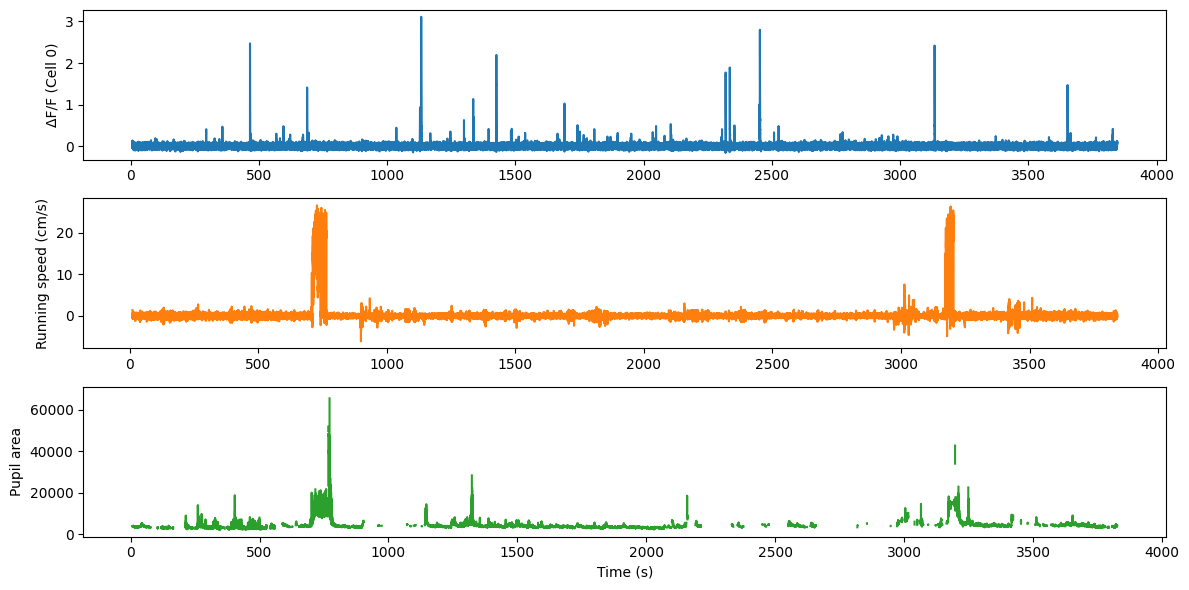

In [12]:
# plot one cell + behavioral variables
plt.figure(figsize=(12, 6))
plt.subplot(3,1,1)
plt.plot(timestamps, dff_traces[0], color='tab:blue')
plt.ylabel('ΔF/F (Cell 0)')

plt.subplot(3,1,2)
plt.plot(timestamps, aligned_dx, color='tab:orange')
plt.ylabel('Running speed (cm/s)')

plt.subplot(3,1,3)
plt.plot(timestamps, pupil_aligned, color='tab:green')
plt.ylabel('Pupil area')
plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()

In [13]:
# choose the naturalistic stimulus (can also try 'natural_scenes')
STIM = 'natural_movie_three'

stim_table = data_set.get_stimulus_table(STIM)
print(stim_table.head())
print("Columns:", list(stim_table.columns))
print("Number of stimulus presentations:", len(stim_table))

   frame  start    end  repeat
0      0  19743  19744       0
1      1  19744  19745       0
2      2  19745  19746       0
3      3  19746  19747       0
4      4  19747  19748       0
Columns: ['frame', 'start', 'end', 'repeat']
Number of stimulus presentations: 36000


In [14]:
# identify trial start times
if 'frame' in stim_table.columns:
    trial_starts = stim_table.loc[stim_table.frame == 0, 'start'].values
else:
    trial_starts = stim_table['start'].values

print("Number of trials:", len(trial_starts))

Number of trials: 10


In [15]:
#Estimate average trial duration
if len(trial_starts) > 1:
    sweep_len = np.median(np.diff(trial_starts))
else:
    sweep_len = np.median(stim_table['end'] - stim_table['start'])

print("Estimated sweep length (s):", sweep_len)


Estimated sweep length (s): 3620.0


In [17]:
print("Available stimuli in this experiment:")
print(data_set.list_stimuli())

Available stimuli in this experiment:
['drifting_gratings', 'natural_movie_one', 'natural_movie_three', 'spontaneous']


In [18]:
STIM = 'natural_movie_three'
stim_table = data_set.get_stimulus_table(STIM)
print(stim_table.head(10))
print("Columns:", list(stim_table.columns))
print("Number of stimulus presentations:", len(stim_table))

   frame  start    end  repeat
0      0  19743  19744       0
1      1  19744  19745       0
2      2  19745  19746       0
3      3  19746  19747       0
4      4  19747  19748       0
5      5  19748  19749       0
6      6  19749  19750       0
7      7  19750  19751       0
8      8  19751  19752       0
9      9  19752  19753       0
Columns: ['frame', 'start', 'end', 'repeat']
Number of stimulus presentations: 36000


In [19]:
if 'frame' in stim_table.columns:
    trial_starts = stim_table.loc[stim_table['frame'] == 0, 'start'].values
else:
    trial_starts = stim_table['start'].values

print("Trial starts found:", len(trial_starts))

# Determine sweep length safely
if len(trial_starts) > 1:
    sweep_len = np.median(np.diff(trial_starts))
elif 'end' in stim_table.columns:
    sweep_len = np.median(stim_table['end'] - stim_table['start'])
else:
    sweep_len = 30  # fallback (30 s)
    
print("Estimated sweep length:", sweep_len)

Trial starts found: 10
Estimated sweep length: 3620.0


In [20]:
for i, s in enumerate(trial_starts[:5]):
    win = (timestamps >= s) & (timestamps < s + sweep_len)
    print(f"Trial {i}: {win.sum()} frames inside window")

Trial 0: 0 frames inside window
Trial 1: 0 frames inside window
Trial 2: 0 frames inside window
Trial 3: 0 frames inside window
Trial 4: 0 frames inside window


In [21]:
frame_rate = 30.0  # approximate imaging frame rate (Hz)
trial_starts = trial_starts / frame_rate
sweep_len = sweep_len / frame_rate
print("Converted trial_starts to seconds.")

Converted trial_starts to seconds.


In [22]:
trial_responses = []
trial_running = []
trial_pupil = []

for s in trial_starts:
    win = (timestamps >= s) & (timestamps < s + sweep_len)
    if win.sum() == 0:
        continue
    trial_responses.append(np.nanmean(dff_traces[:, win], axis=1))
    trial_running.append(np.nanmean(aligned_dx[win]))
    trial_pupil.append(np.nanmean(pupil_aligned[win]))

trial_responses = np.vstack(trial_responses)
trial_running = np.array(trial_running)
trial_pupil = np.array(trial_pupil)

print("trial_responses shape:", trial_responses.shape)

trial_responses shape: (10, 209)


In [23]:
import statsmodels.api as sm
import pandas as pd

# Build predictors
X = np.column_stack([
    trial_running,
    trial_pupil,
    trial_running * trial_pupil
])
X = sm.add_constant(X)  # adds intercept column
print("Design matrix shape:", X.shape)

Design matrix shape: (10, 4)


In [24]:
n_trials, n_cells = trial_responses.shape
betas = np.full((n_cells, X.shape[1]), np.nan)
pvals = np.full_like(betas, np.nan)
r2s = np.full((n_cells,), np.nan)

for c in range(n_cells):
    y = trial_responses[:, c]
    valid = ~np.isnan(y) & ~np.isnan(X).any(axis=1)
    if valid.sum() <= X.shape[1]:
        continue
    model = sm.OLS(y[valid], X[valid]).fit()
    betas[c, :] = model.params
    pvals[c, :] = model.pvalues
    r2s[c] = model.rsquared

# Store as DataFrame for clarity
df_betas = pd.DataFrame(betas, columns=['const', 'running', 'pupil', 'run_x_pupil'])
df_betas['r2'] = r2s
df_betas.head()

,const,running,pupil,run_x_pupil,r2
0,0.016206,0.339915,-0.000003,-0.000035,0.053501
1,0.022784,1.757168,-0.000002,-0.000183,0.427879
2,-0.002894,-0.637085,0.000002,0.000066,0.724431
3,0.016327,0.812742,-0.000001,-0.000085,0.617026
4,-0.005145,-0.409518,0.000003,0.000042,0.395290


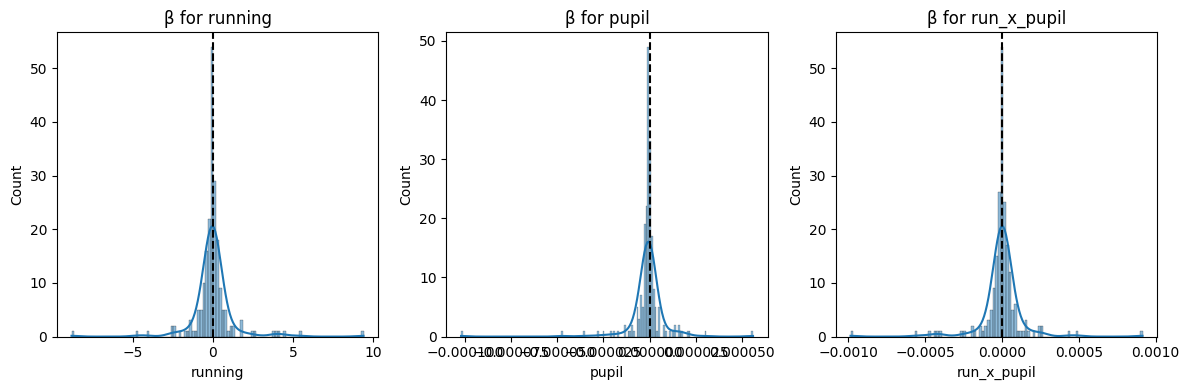

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,4))
for i, var in enumerate(['running', 'pupil', 'run_x_pupil']):
    plt.subplot(1,3,i+1)
    sns.histplot(df_betas[var].dropna(), kde=True)
    plt.title(f"β for {var}")
    plt.axvline(0, color='k', linestyle='--')
plt.tight_layout()
plt.show()


In [26]:
# stimulus window mask (frames inside the movie)
stim_table = data_set.get_stimulus_table('natural_movie_three')
trial_starts = stim_table.loc[stim_table['frame'] == 0, 'start'].values
sweep_len = np.median(np.diff(trial_starts))
mask = np.zeros_like(timestamps, dtype=bool)
for s in trial_starts:
    mask |= (timestamps >= s) & (timestamps < s + sweep_len)
print("Frames during stimulus:", mask.sum(), "/", len(mask))

# subset to those frames
Y = dff_traces[:, mask]                # (n_cells, n_frames)
run_vec = aligned_dx[mask]
pupil_vec = pupil_aligned[mask]

Frames during stimulus: 0 / 115728


In [27]:
STIM = 'natural_movie_three'
stim_table = data_set.get_stimulus_table(STIM)
print(stim_table.head(10))
print("Columns:", list(stim_table.columns))
print("Min start:", stim_table['start'].min(), "Max start:", stim_table['start'].max())
print("Unique frame values:", stim_table['frame'].unique()[:10])


   frame  start    end  repeat
0      0  19743  19744       0
1      1  19744  19745       0
2      2  19745  19746       0
3      3  19746  19747       0
4      4  19747  19748       0
5      5  19748  19749       0
6      6  19749  19750       0
7      7  19750  19751       0
8      8  19751  19752       0
9      9  19752  19753       0
Columns: ['frame', 'start', 'end', 'repeat']
Min start: 19743 Max start: 93961
Unique frame values: [0 1 2 3 4 5 6 7 8 9]


In [28]:
# Convert start/end from frame indices to seconds
frame_rate = 30.0  # typical for 2P data
stim_table['start_sec'] = stim_table['start'] / frame_rate
stim_table['end_sec'] = stim_table['end'] / frame_rate

# Build mask: mark frames within any stimulus window
mask = np.zeros_like(timestamps, dtype=bool)
for s, e in zip(stim_table['start_sec'], stim_table['end_sec']):
    mask |= (timestamps >= s) & (timestamps <= e)

print("Frames during stimulus:", mask.sum(), "/", len(mask))

Frames during stimulus: 18170 / 115728


In [2]:
plt.figure(figsize=(10,2))
plt.plot(timestamps, aligned_dx, label='Running', alpha=0.6)
plt.plot(timestamps[mask], aligned_dx[mask], '.', label='Stimulus frames', markersize=1)
plt.legend()
plt.title("Running trace with stimulus mask overlay")
plt.show()

NameError: name 'plt' is not defined

Data shapes: (209, 18170) (18170,) (18170,)
Predictor matrix shape: (18170, 4)
      const   running     pupil  run_x_pupil        r2
0  0.003971 -0.002062  0.000251     0.001370  0.000187
1  0.014741 -0.003874 -0.000596     0.001344  0.000567
2  0.007246  0.007210  0.013171    -0.012540  0.018524
3  0.013622 -0.004378  0.001251     0.000683  0.001078
4  0.008316 -0.003882 -0.001756     0.003591  0.000732


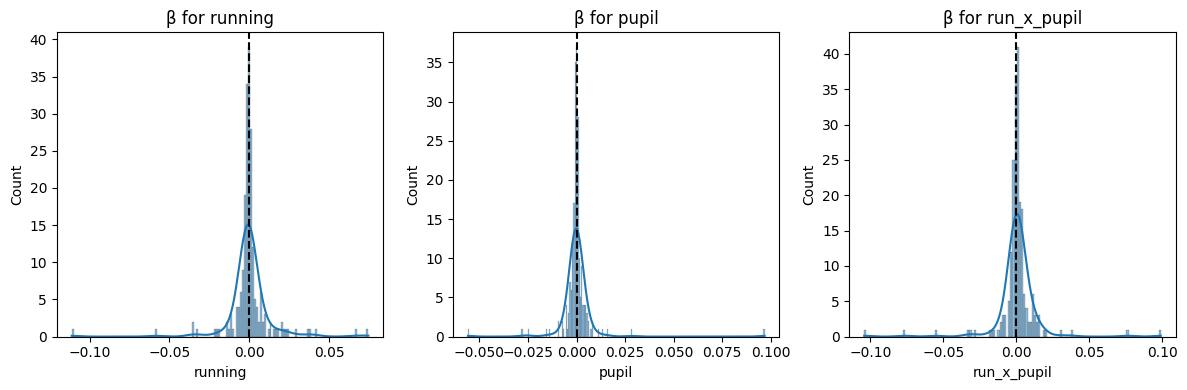

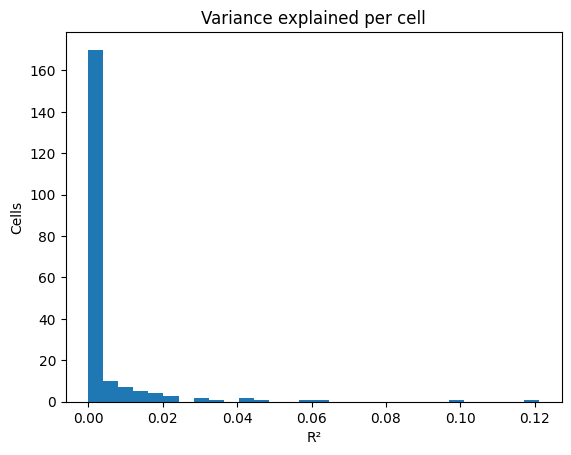

Saved as framewise_glm_results_exp528402271.csv


In [30]:
# =============================================
# FRAME-LEVEL GLM  (Objective 3b)
# =============================================

from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Prepare data ---
Y = dff_traces[:, mask]                # (n_cells, n_frames_in_stim)
run_vec = aligned_dx[mask]
pupil_vec = pupil_aligned[mask]

print("Data shapes:", Y.shape, run_vec.shape, pupil_vec.shape)

# --- Handle any NaNs (replace with mean) ---
run_vec = np.nan_to_num(run_vec, nan=np.nanmean(run_vec))
pupil_vec = np.nan_to_num(pupil_vec, nan=np.nanmean(pupil_vec))

# --- Standardize predictors for numerical stability ---
scaler = StandardScaler()
X_vars = np.column_stack([run_vec, pupil_vec, run_vec * pupil_vec])
X_scaled = scaler.fit_transform(X_vars)
X = np.column_stack([np.ones(X_scaled.shape[0]), X_scaled])  # add intercept

print("Predictor matrix shape:", X.shape)

# --- Vectorized regression (fast least squares) ---
betas_framewise = np.linalg.lstsq(X, Y.T, rcond=None)[0].T   # (n_cells, 4)
pred = (X @ betas_framewise.T).T
ss_res = np.sum((Y - pred)**2, axis=1)
ss_tot = np.sum((Y - np.mean(Y, axis=1, keepdims=True))**2, axis=1)
r2_framewise = 1 - ss_res/ss_tot

# --- Wrap results ---
df_frame_betas = pd.DataFrame(
    betas_framewise,
    columns=['const','running','pupil','run_x_pupil']
)
df_frame_betas['r2'] = r2_framewise
print(df_frame_betas.head())

# --- Plot coefficient distributions ---
plt.figure(figsize=(12,4))
for i, var in enumerate(['running','pupil','run_x_pupil']):
    plt.subplot(1,3,i+1)
    sns.histplot(df_frame_betas[var], kde=True)
    plt.axvline(0, color='k', linestyle='--')
    plt.title(f"β for {var}")
plt.tight_layout()
plt.show()

# --- Plot variance explained ---
plt.hist(df_frame_betas['r2'], bins=30)
plt.xlabel('R²'); plt.ylabel('Cells'); plt.title('Variance explained per cell')
plt.show()

# --- Save results ---
df_frame_betas.to_csv("framewise_glm_results_exp528402271.csv", index=False)
print("Saved as framewise_glm_results_exp528402271.csv")

In [31]:
#Step 1 — Run PCA on population activity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Use the same mask-restricted fluorescence matrix
Y = dff_traces[:, mask].T      # shape (frames × cells)

# Standardize each neuron's activity (z-score)
Y_z = (Y - Y.mean(axis=0)) / Y.std(axis=0)

# Run PCA
pca = PCA(n_components=10)
pcs = pca.fit_transform(Y_z)    # (frames × components)

print("Explained variance ratio:", pca.explained_variance_ratio_[:5])
print("pcs shape:", pcs.shape)

Explained variance ratio: [0.03096294 0.01272574 0.01174046 0.0107813  0.01045982]
pcs shape: (18170, 10)


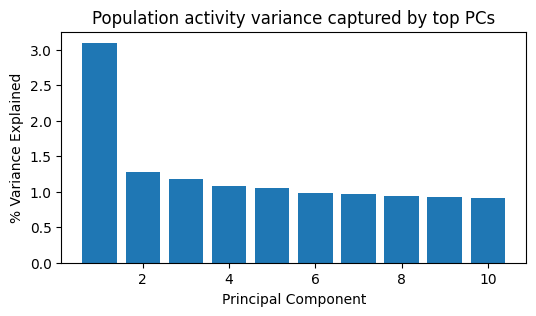

In [32]:
plt.figure(figsize=(6,3))
plt.bar(range(1,11), pca.explained_variance_ratio_[:10]*100)
plt.xlabel('Principal Component')
plt.ylabel('% Variance Explained')
plt.title('Population activity variance captured by top PCs')
plt.show()

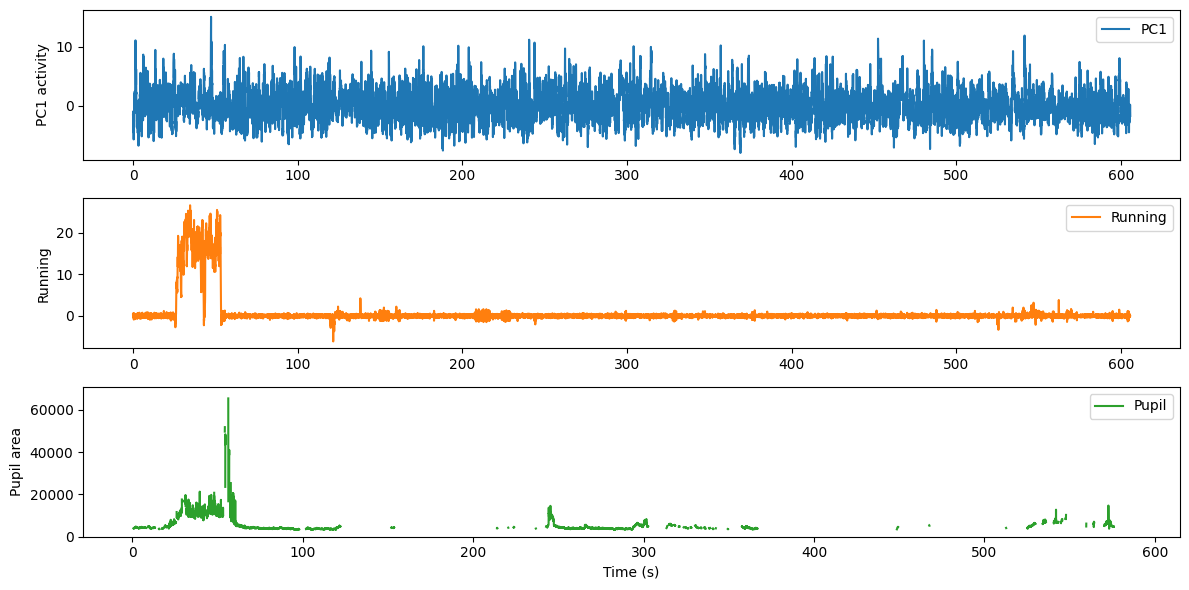

In [33]:
#Visualize PC time-series vs behavioral state
time_axis = np.arange(pcs.shape[0]) / 30  # assuming 30 Hz
plt.figure(figsize=(12,6))
plt.subplot(3,1,1)
plt.plot(time_axis, pcs[:,0], label='PC1', color='tab:blue')
plt.ylabel('PC1 activity'); plt.legend()
plt.subplot(3,1,2)
plt.plot(time_axis, aligned_dx[mask], label='Running', color='tab:orange')
plt.ylabel('Running'); plt.legend()
plt.subplot(3,1,3)
plt.plot(time_axis, pupil_aligned[mask], label='Pupil', color='tab:green')
plt.xlabel('Time (s)'); plt.ylabel('Pupil area'); plt.legend()
plt.tight_layout()
plt.show()

In [34]:
n_pc = 5
X = np.column_stack([
    aligned_dx[mask],
    pupil_aligned[mask],
    aligned_dx[mask] * pupil_aligned[mask]
])
X = sm.add_constant(X)

betas_pc = []
r2_pc = []
for i in range(n_pc):
    model = sm.OLS(pcs[:,i], X, missing='drop').fit()
    betas_pc.append(model.params)
    r2_pc.append(model.rsquared)

df_pc = pd.DataFrame(betas_pc,
                     columns=['const','running','pupil','run_x_pupil'])
df_pc['r2'] = r2_pc
df_pc.index = [f'PC{i+1}' for i in range(n_pc)]
print(df_pc)

        const   running     pupil   run_x_pupil        r2
PC1 -0.043275 -0.061172  0.000016  7.352302e-06  0.006177
PC2  0.422092  0.052916 -0.000037 -4.476511e-06  0.006004
PC3  0.215064 -0.227878  0.000046  1.083157e-05  0.075184
PC4 -0.103858  0.087929  0.000026  3.279781e-06  0.220811
PC5 -0.198075  0.059272  0.000012 -7.899663e-07  0.037514


In [ ]:
#Objective 5

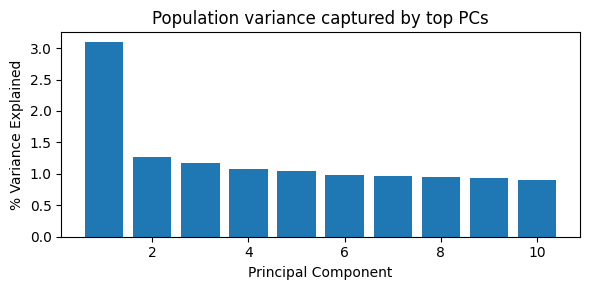

In [35]:
plt.figure(figsize=(6,3))
plt.bar(range(1,11), pca.explained_variance_ratio_[:10]*100, color='tab:blue')
plt.xlabel('Principal Component')
plt.ylabel('% Variance Explained')
plt.title('Population variance captured by top PCs')
plt.tight_layout()
plt.show()

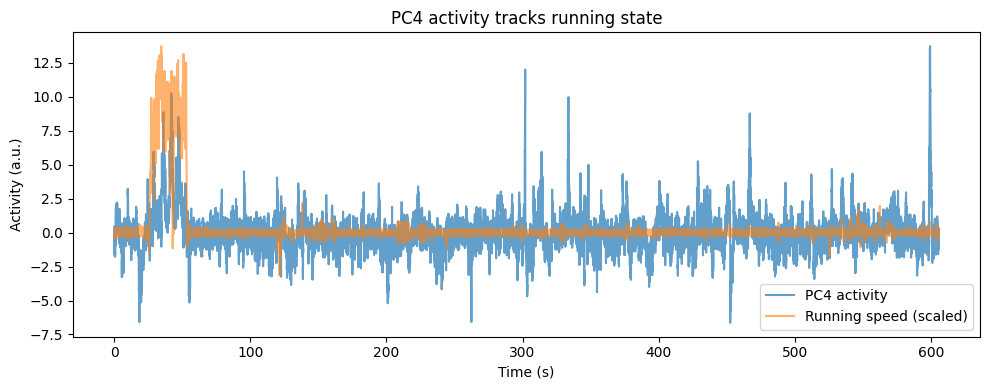

In [36]:
pc_index = 3  # zero-based index for PC4
time_axis = np.arange(pcs.shape[0]) / 30  # seconds (assuming 30 Hz)

plt.figure(figsize=(10,4))
plt.plot(time_axis, pcs[:, pc_index], label='PC4 activity', color='tab:blue', alpha=0.7)
plt.plot(time_axis, aligned_dx[mask]/np.nanmax(aligned_dx[mask])*np.nanmax(pcs[:, pc_index]),
         label='Running speed (scaled)', color='tab:orange', alpha=0.6)
plt.xlabel('Time (s)')
plt.ylabel('Activity (a.u.)')
plt.legend()
plt.title('PC4 activity tracks running state')
plt.tight_layout()
plt.show()

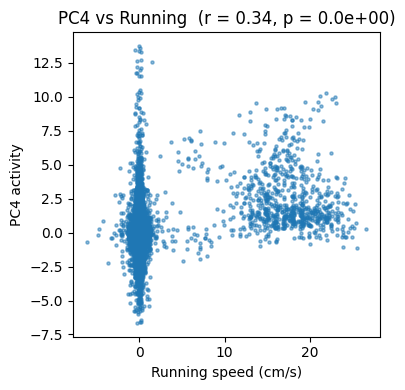

In [37]:
import scipy.stats as stats

plt.figure(figsize=(4,4))
plt.scatter(aligned_dx[mask], pcs[:, pc_index], s=5, alpha=0.5)
r, p = stats.pearsonr(aligned_dx[mask], pcs[:, pc_index])
plt.xlabel('Running speed (cm/s)')
plt.ylabel('PC4 activity')
plt.title(f'PC4 vs Running  (r = {r:.2f}, p = {p:.1e})')
plt.tight_layout()
plt.show()

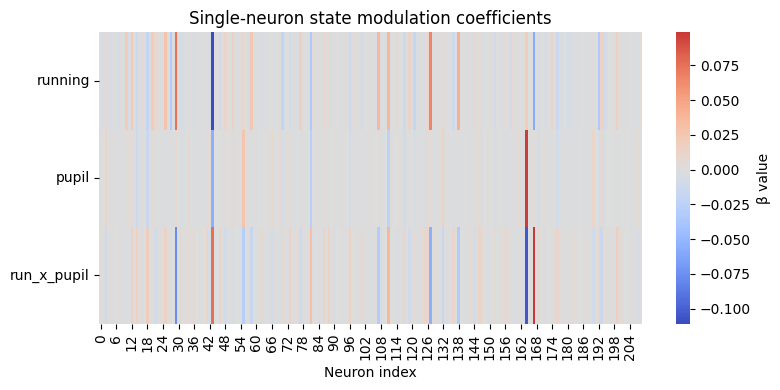

In [40]:
#Scatter and correlation plot
import seaborn as sns
plt.figure(figsize=(8,4))
sns.heatmap(df_frame_betas[['running','pupil','run_x_pupil']].T,
            cmap='coolwarm', center=0, cbar_kws={'label':'β value'})
plt.yticks(rotation=0)
plt.xlabel('Neuron index')
plt.title('Single-neuron state modulation coefficients')
plt.tight_layout()
plt.show()

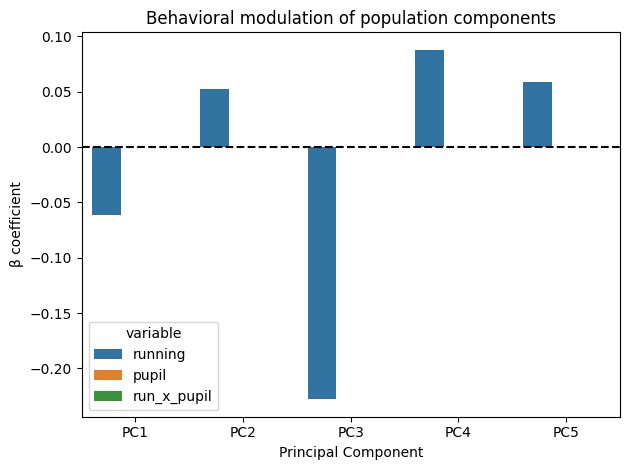

In [39]:
#Summary plot of population β coefficients
sns.barplot(data=df_pc.reset_index().melt(id_vars='index',
                                          value_vars=['running','pupil','run_x_pupil']),
            x='index', y='value', hue='variable')
plt.axhline(0, color='k', linestyle='--')
plt.ylabel('β coefficient')
plt.xlabel('Principal Component')
plt.title('Behavioral modulation of population components')
plt.tight_layout()
plt.show()


In [42]:
df_frame_betas_VISp = df_frame_betas.copy()

In [43]:
exp_id_VISal = 580043440
data_VISal = boc.get_ophys_experiment_data(exp_id_VISal)

In [44]:
df_frame_betas

,const,running,pupil,run_x_pupil,r2
0,0.003971,-0.002062,0.000251,0.001370,0.000187
1,0.014741,-0.003874,-0.000596,0.001344,0.000567
2,0.007246,0.007210,0.013171,-0.012540,0.018524
3,0.013622,-0.004378,0.001251,0.000683,0.001078
4,0.008316,-0.003882,-0.001756,0.003591,0.000732
...,...,...,...,...,...
204,0.005475,-0.000652,-0.002166,0.000890,0.001026
205,0.006646,-0.001640,-0.001654,0.001531,0.000392
206,0.007033,-0.001616,-0.000172,0.000760,0.000270
207,0.022782,-0.003091,0.004577,-0.004253,0.001499


In [45]:
df_frame_betas_VISal = df_frame_betas.copy()

C:\Users\user\AppData\Local\Temp\ipykernel_5816\1388055510.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=comparison, x='region', y='beta_running', palette='Set2')


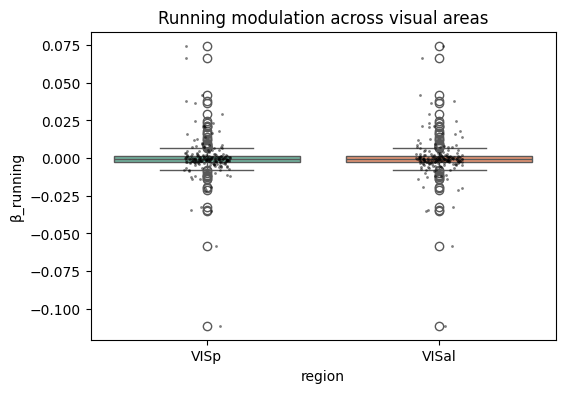

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    'region': ['VISp']*len(df_frame_betas_VISp) + ['VISal']*len(df_frame_betas_VISal),
    'beta_running': np.concatenate([df_frame_betas_VISp['running'], df_frame_betas_VISal['running']]),
    'beta_pupil': np.concatenate([df_frame_betas_VISp['pupil'], df_frame_betas_VISal['pupil']]),
    'r2': np.concatenate([df_frame_betas_VISp['r2'], df_frame_betas_VISal['r2']])
})

plt.figure(figsize=(6,4))
sns.boxplot(data=comparison, x='region', y='beta_running', palette='Set2')
sns.stripplot(data=comparison, x='region', y='beta_running', color='k', size=2, alpha=0.5)
plt.title('Running modulation across visual areas')
plt.ylabel('β_running')
plt.show()

In [52]:
def analyze_experiment(exp_id, boc, stim_name='natural_movie_three', frame_rate=30.0):
    """
    Run frame-level GLM for a given experiment ID.
    Returns a DataFrame of regression coefficients per neuron.
    """
    import numpy as np
    import pandas as pd
    from sklearn.preprocessing import StandardScaler
    
    data_set = boc.get_ophys_experiment_data(exp_id)
    print(f"Analyzing experiment {exp_id}")
    
    # Extract dF/F traces
    dff_traces = data_set.get_dff_traces()[1]  # shape: (n_cells, n_frames)
    timestamps = data_set.get_corrected_fluorescence_traces()[2]  # get frame timestamps
    
    # Running data
    dxcm, dxtime = data_set.get_running_speed()
    aligned_dx = np.interp(timestamps, dxtime, dxcm)
    
    # Pupil data (if available)
    try:
        pupil_data = data_set.get_pupil_size()
        pupil_aligned = np.interp(timestamps, pupil_data['timestamps'], pupil_data['pupil_area'])
    except Exception:
        pupil_aligned = np.zeros_like(timestamps)
        print("No pupil data available, setting to zero.")
    
    # Stimulus window
    stim_table = data_set.get_stimulus_table(stim_name)
    stim_table['start_sec'] = stim_table['start'] / frame_rate
    stim_table['end_sec'] = stim_table['end'] / frame_rate
    mask = np.zeros_like(timestamps, dtype=bool)
    for s, e in zip(stim_table['start_sec'], stim_table['end_sec']):
        mask |= (timestamps >= s) & (timestamps <= e)
    
    print(f"Frames during stimulus: {mask.sum()} / {len(mask)}")
    
    # Prepare data
    Y = dff_traces[:, mask]
    run_vec = np.nan_to_num(aligned_dx[mask], nan=np.nanmean(aligned_dx))
    pupil_vec = np.nan_to_num(pupil_aligned[mask], nan=np.nanmean(pupil_aligned))
    
    # Standardize predictors
    scaler = StandardScaler()
    X_vars = np.column_stack([run_vec, pupil_vec, run_vec * pupil_vec])
    X_scaled = scaler.fit_transform(X_vars)
    X = np.column_stack([np.ones(X_scaled.shape[0]), X_scaled])
    
    # Vectorized regression
    betas = np.linalg.lstsq(X, Y.T, rcond=None)[0].T
    pred = (X @ betas.T).T
    ss_res = np.sum((Y - pred)**2, axis=1)
    ss_tot = np.sum((Y - np.mean(Y, axis=1, keepdims=True))**2, axis=1)
    r2 = 1 - ss_res/ss_tot
    
    df = pd.DataFrame(betas, columns=['const','running','pupil','run_x_pupil'])
    df['r2'] = r2
    df['exp_id'] = exp_id
    return df

In [55]:
def analyze_experiment(exp_id, boc, stim_name='natural_movie_three', frame_rate=30.0):
    """
    Run frame-level GLM for a given Allen Brain Observatory 2P experiment (old SDK version).
    Returns a DataFrame of regression coefficients per neuron.
    """
    import numpy as np
    import pandas as pd
    from sklearn.preprocessing import StandardScaler
    
    data_set = boc.get_ophys_experiment_data(exp_id)
    print(f"Analyzing experiment {exp_id}")
    
    # Extract dF/F traces
    dff_traces = data_set.get_dff_traces()[1]  # shape: (n_cells, n_frames)
    
    # ✅ Old SDK method to get timestamps
    timestamps = data_set.get_stimulus_epoch_table().index.values
    if len(timestamps) == 0:
        try:
            timestamps = data_set.get_running_speed()[1]
        except Exception:
            timestamps = np.arange(dff_traces.shape[1]) / frame_rate
    
    # Running data
    dxcm, dxtime = data_set.get_running_speed()
    aligned_dx = np.interp(np.arange(dff_traces.shape[1]), np.arange(len(dxcm)), dxcm)
    
    # Pupil data (if available)
    try:
        pupil_data = data_set.get_pupil_size()
        pupil_aligned = np.interp(np.arange(dff_traces.shape[1]), 
                                  np.arange(len(pupil_data['pupil_area'])), 
                                  pupil_data['pupil_area'])
    except Exception:
        pupil_aligned = np.zeros(dff_traces.shape[1])
        print("No pupil data available, setting to zero.")
    
    # Stimulus window
    stim_table = data_set.get_stimulus_table(stim_name)
    mask = np.zeros(dff_traces.shape[1], dtype=bool)
    for s, e in zip(stim_table['start'], stim_table['end']):
        mask[s:e] = True
    
    print(f"Frames during stimulus: {mask.sum()} / {len(mask)}")
    
    # Prepare data
    Y = dff_traces[:, mask]
    run_vec = np.nan_to_num(aligned_dx[mask], nan=np.nanmean(aligned_dx))
    pupil_vec = np.nan_to_num(pupil_aligned[mask], nan=np.nanmean(pupil_aligned))
    
    # Standardize predictors
    scaler = StandardScaler()
    X_vars = np.column_stack([run_vec, pupil_vec, run_vec * pupil_vec])
    X_scaled = scaler.fit_transform(X_vars)
    X = np.column_stack([np.ones(X_scaled.shape[0]), X_scaled])
    
    # Vectorized regression
    betas = np.linalg.lstsq(X, Y.T, rcond=None)[0].T
    pred = (X @ betas.T).T
    ss_res = np.sum((Y - pred)**2, axis=1)
    ss_tot = np.sum((Y - np.mean(Y, axis=1, keepdims=True))**2, axis=1)
    r2 = 1 - ss_res/ss_tot
    
    df = pd.DataFrame(betas, columns=['const','running','pupil','run_x_pupil'])
    df['r2'] = r2
    df['exp_id'] = exp_id
    return df


In [56]:
exp_VISp = 528402271
exp_VISal = 580043440

df_VISp = analyze_experiment(exp_VISp, boc)
df_VISal = analyze_experiment(exp_VISal, boc)

Analyzing experiment 528402271
No pupil data available, setting to zero.
Frames during stimulus: 18081 / 115728
Analyzing experiment 580043440
No pupil data available, setting to zero.
Frames during stimulus: 18074 / 115457


C:\Users\user\AppData\Local\Temp\ipykernel_5816\3292403075.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=comparison, x='region', y='beta_running', palette='Set2')


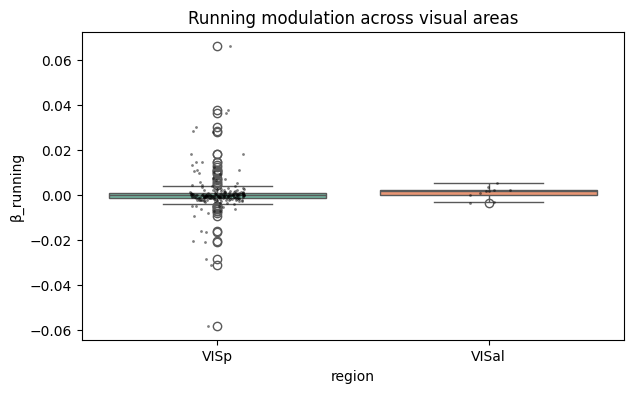

C:\Users\user\AppData\Local\Temp\ipykernel_5816\3292403075.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=comparison, x='region', y='r2', palette='Set2')


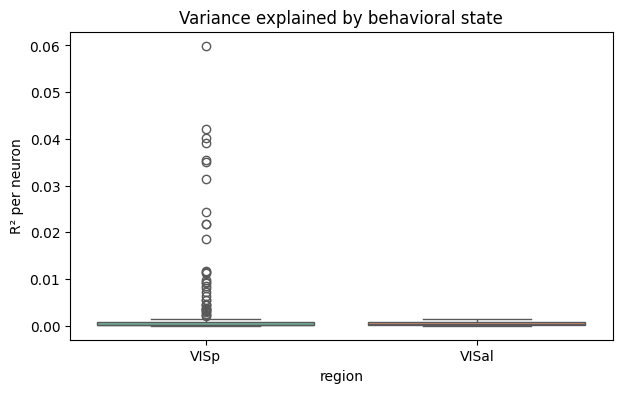

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

comparison = pd.DataFrame({
    'region': ['VISp']*len(df_VISp) + ['VISal']*len(df_VISal),
    'beta_running': np.concatenate([df_VISp['running'], df_VISal['running']]),
    'beta_pupil': np.concatenate([df_VISp['pupil'], df_VISal['pupil']]),
    'r2': np.concatenate([df_VISp['r2'], df_VISal['r2']])
})

plt.figure(figsize=(7,4))
sns.boxplot(data=comparison, x='region', y='beta_running', palette='Set2')
sns.stripplot(data=comparison, x='region', y='beta_running', color='k', alpha=0.5, size=2)
plt.title('Running modulation across visual areas')
plt.ylabel('β_running')
plt.show()

plt.figure(figsize=(7,4))
sns.boxplot(data=comparison, x='region', y='r2', palette='Set2')
plt.title('Variance explained by behavioral state')
plt.ylabel('R² per neuron')
plt.show()